# Personal Health Activity Tracker
## AAI-530 (sp25) Group 5 Final Project

Robair Farag, Michael De Leon, Geoffrey Fadera

University of San Diego, Applied Artificial Intelligence

Date:  February 24, 2025

GitHub Repository: https://github.com/Robairfarag1/Personal-Health-Activity-Tracker

## Project Overview

**Dataset**
Human Activity Recognition Using Smartphones Dataset
https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

**Two Tasks for Machine Learning**
Based on how the dataset was collected and formatted, the team decided to work on the following tasks where Machine Learning can be applied
1. In real-time, given the most recent 128 sensor readings, classify the human activity
2. In real-time, given the most recent 64 sensor readings, predict the next 64


# Part I: Exploratory Data Analysis (EDA) and Pre-processing

## Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
from importlib import reload
import keras

import numpy as np
from sklearn.preprocessing import LabelEncoder

# KERAS RANDOM SEED FOR REPRODUCIBILITY
keras.utils.set_random_seed(1234)
np.random.seed(1234)  
PYTHONHASHSEED = 0

## Data Loading, Preprocessing, and Analysis


In [2]:
# DATASET PATH 
DATASET_DIR = '../Dataset'

In [3]:
# Load Human Activity Labels, and Available Features

# Define file paths
activity_labels_path = f"{DATASET_DIR}/activity_labels.txt"
features_path = f"{DATASET_DIR}/features.txt"

# ✅ Load activity<->label mappings
activity_labels = pd.read_csv(activity_labels_path, header=None, sep=' ', names=['id', 'activity'])
activity_labels.set_index('id', inplace=True)  # Set index for easy mapping

# ✅ Load feature names
features = pd.read_csv(features_path, header=None, sep=' ', names=['id', 'feature_name'])

# Define file paths for train and test data
train_path = f"{DATASET_DIR}/train/"
test_path = f"{DATASET_DIR}/test/"

# ✅ Load subject, X (features), and y (labels) for training
subject_train = pd.read_csv(train_path + "subject_train.txt", header=None, names=['subject'])
X_train = pd.read_csv(train_path + "X_train.txt", sep=r'\s+', header=None)
y_train = pd.read_csv(train_path + "y_train.txt", header=None, names=['activity'])

# ✅ Load subject, X (features), and y (labels) for testing
subject_test = pd.read_csv(test_path + "subject_test.txt", header=None, names=['subject'])
X_test = pd.read_csv(test_path + "X_test.txt", sep=r'\s+', header=None)
y_test = pd.read_csv(test_path + "y_test.txt", header=None, names=['activity'])

# ✅ Assign feature names to X_train & X_test
X_train.columns = features["feature_name"]
X_test.columns = features["feature_name"]

# ✅ Convert activity numbers to labels
y_train["activity"] = y_train["activity"].map(activity_labels["activity"])
y_test["activity"] = y_test["activity"].map(activity_labels["activity"])

# ✅ Combine subject, activity, and features into final datasets
train_data = pd.concat([subject_train, y_train, X_train], axis=1)
test_data = pd.concat([subject_test, y_test, X_test], axis=1)


# Display loaded data
print("✅ Human Activity Label Mapping:")
print(activity_labels)

print("\n✅ Features Preview:")
print(features.head())

# Display dataset info
print("🔍 Train Dataset Info:")
train_data.info()
print("\n🔍 Test Dataset Info:")
test_data.info()

# Preview the first few rows
print("\n📌 Train Data Preview:")
display(train_data.head())

print("\n📌 Test Data Preview:")
display(test_data.head())

# Check for missing values
print("\n❓ Missing Values in Train Data:")
print(train_data.isnull().sum().sum())

print("\n❓ Missing Values in Test Data:")
print(test_data.isnull().sum().sum())



✅ Human Activity Label Mapping:
              activity
id                    
1              WALKING
2     WALKING_UPSTAIRS
3   WALKING_DOWNSTAIRS
4              SITTING
5             STANDING
6               LAYING

✅ Features Preview:
   id       feature_name
0   1  tBodyAcc-mean()-X
1   2  tBodyAcc-mean()-Y
2   3  tBodyAcc-mean()-Z
3   4   tBodyAcc-std()-X
4   5   tBodyAcc-std()-Y
🔍 Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, subject to angle(Z,gravityMean)
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB

🔍 Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 563 entries, subject to angle(Z,gravityMean)
dtypes: float64(561), int64(1), object(1)
memory usage: 12.7+ MB

📌 Train Data Preview:


,subject,activity,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,STANDING,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,STANDING,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,STANDING,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,STANDING,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,STANDING,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892



📌 Test Data Preview:


,subject,activity,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,2,STANDING,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,...,0.071645,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978
1,2,STANDING,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,...,-0.401189,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898
2,2,STANDING,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,...,0.062891,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346
3,2,STANDING,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,...,0.116695,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108
4,2,STANDING,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,...,-0.121711,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857



❓ Missing Values in Train Data:
0

❓ Missing Values in Test Data:
0


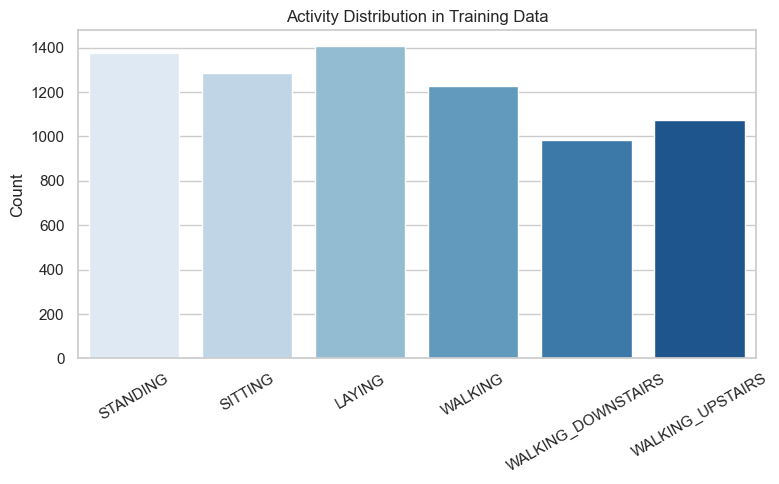

In [4]:
# Suppress warnings
#warnings.simplefilter(action="ignore", category=FutureWarning)
#warnings.simplefilter(action="ignore", category=UserWarning)

# Since the dataset has already been split into TRAIN and TEST sets, perform EDA EXCLUSIVELY on Train Data

# Set style for plots
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Count activity labels in train and test datasets
plt.figure(figsize=(8, 5))

# Training Set
sns.countplot(data=train_data, x="activity", hue="activity", palette="Blues", legend=False)
plt.title("Activity Distribution in Training Data")
plt.xlabel(xlabel=None)
plt.ylabel("Count")
plt.xticks(rotation=30)


plt.tight_layout()
plt.show()

In [5]:
# Summary statistics of numerical columns
print("📌 Summary Statistics (Train Data):")
display(train_data.describe())

print("\n📌 Summary Statistics (Test Data):")
display(test_data.describe())


📌 Summary Statistics (Train Data):


,subject,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,17.413085,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,8.975143,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8.000000,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,19.000000,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,26.000000,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,30.000000,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000



📌 Summary Statistics (Test Data):


,subject,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,12.986427,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.641278,-0.522676,-0.637038,...,0.130236,-0.277593,-0.598756,0.005264,0.003799,0.040029,-0.017298,-0.513923,0.074886,-0.048720
std,6.950984,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.385199,0.479899,0.357753,...,0.231018,0.317245,0.311042,0.336147,0.445077,0.634989,0.501311,0.509205,0.324300,0.241467
min,2.000000,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999417,-0.999914,-0.998899,...,-0.785543,-1.000000,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228
25%,9.000000,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.992333,-0.974131,-0.975352,...,-0.008433,-0.517494,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,-0.829722,0.022140,-0.098485
50%,12.000000,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.937664,-0.799907,-0.817005,...,0.142676,-0.311023,-0.683672,0.005188,0.006767,0.047113,-0.026726,-0.729648,0.181563,-0.010671
75%,18.000000,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.321719,-0.133488,-0.322771,...,0.288320,-0.083559,-0.458332,0.146200,0.288113,0.622151,0.394387,-0.545939,0.260252,0.092373
max,24.000000,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.439657,1.000000,0.427958,...,1.000000,1.000000,1.000000,0.998898,0.986347,1.000000,1.000000,0.833180,1.000000,0.973113


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import warnings


# Display correlation matrix of available features for a specified sensor
sensor_name='tBodyAcc'

# Suppress font-related warnings
#warnings.simplefilter(action="ignore", category=UserWarning)

# Select a subset of features for correlation analysis
corr_subset = train_data.iloc[:, 2:12].corr()

# Heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", fmt=".2f", square=True)

# Use a simple title to avoid missing glyph warnings
plt.title("Correlation Matrix of Selected Features (Train Data)")

plt.show()


In [7]:
train_data.head()

,subject,activity,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,STANDING,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,STANDING,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,STANDING,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,STANDING,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,STANDING,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


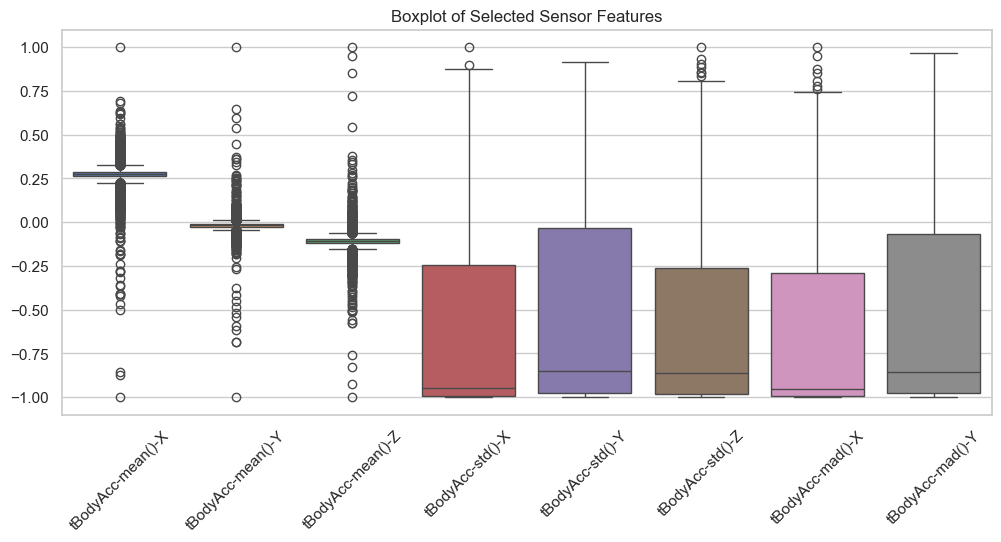

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress font-related warnings
warnings.simplefilter(action="ignore", category=UserWarning)

# Select numerical sensor data for boxplot visualization
plt.figure(figsize=(12, 5))
sns.boxplot(data=train_data.iloc[:, 2:10])

# Use a simple title to avoid missing glyph warnings
plt.title("Boxplot of Selected Sensor Features")

plt.xticks(rotation=45)
plt.show()


Sensor_XYZ_features: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z']


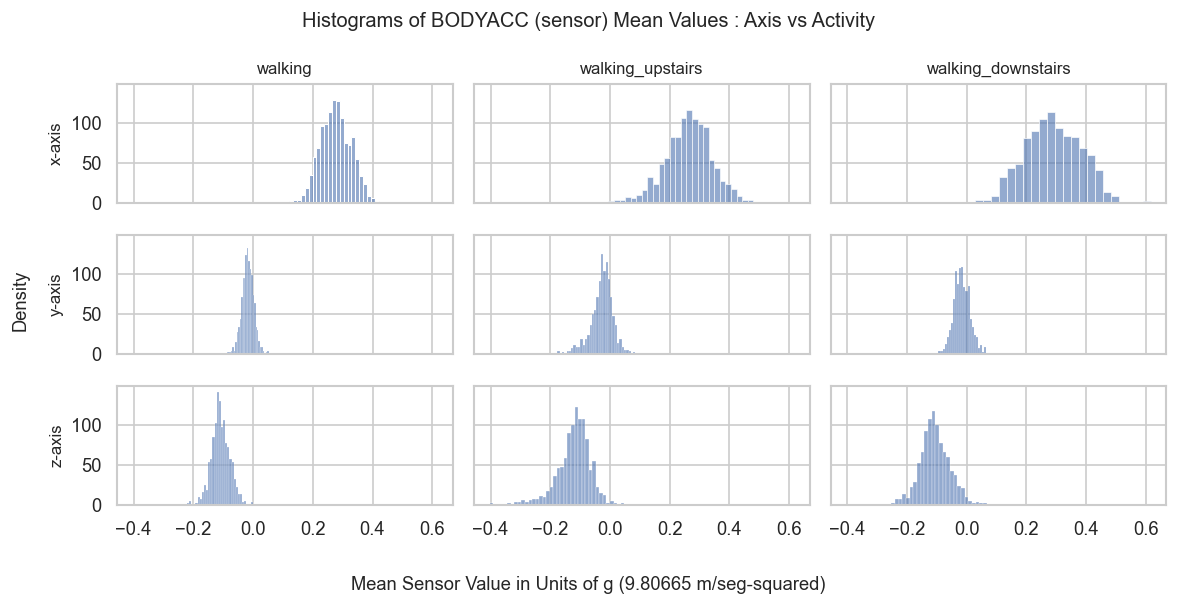

In [15]:
# Compare sensor-feature distributions based on activity
# for each of the six activities, compare the per-axis/per-128 sensor reading - MEAN DISTRIBUTION
# CASE 1: MOBILE + BODYACC
# ACTIVITY = MOBILE {'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'}, SENSOR = BODYACC

actsToAnalyze = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

sensor_name = 'BodyAcc'
sensor_units = {'BodyAcc' : "Units of g (9.80665 m/seg-squared)",
                'BodyGyro' : "radians/seg"}
sensor_unit = sensor_units[sensor_name]
# feature to analyze: always per-axis mean
sensor_XYZ_features = [f't{sensor_name}-mean()-X', 
                       f't{sensor_name}-mean()-Y', 
                       f't{sensor_name}-mean()-Z']
                    
                    

print(f'Sensor_XYZ_features: {sensor_XYZ_features}')
fig=[]
axes=[]

fig, axes = plt.subplots(3, len(actsToAnalyze), figsize=(10, 5), dpi=120, sharex=True, sharey=True)

for act_id, activity in enumerate(actsToAnalyze):
    filtered_train_data = train_data[train_data['activity']==activity]
    # set column title to activity label
    axes[0,act_id].set_title(f"{activity.lower()}", fontsize=10)
    
    for xyz_id, xyz_feature in enumerate(sensor_XYZ_features):
        # display feature stat
        sns.histplot(filtered_train_data[xyz_feature], ax=axes[xyz_id,act_id], fill=True, alpha=0.6)
        axes[xyz_id,0].set_ylabel(f"{xyz_feature[-1].lower()}-axis", fontsize=10)
        axes[xyz_id,act_id].set_xlabel("")

#fig.suptitle(f'Per-Axis MEAN Values for Sensor {sensor_name.upper()}', fontsize=11)
fig.supylabel(f'Density', fontsize=11)
fig.suptitle(f'Histograms of {sensor_name.upper()} (sensor) Mean Values : Axis vs Activity', fontsize=12)
fig.supxlabel(f'Mean Sensor Value in {sensor_unit}', fontsize=11)
plt.tight_layout()

plt.show()



Sensor_XYZ_features: ['tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z']


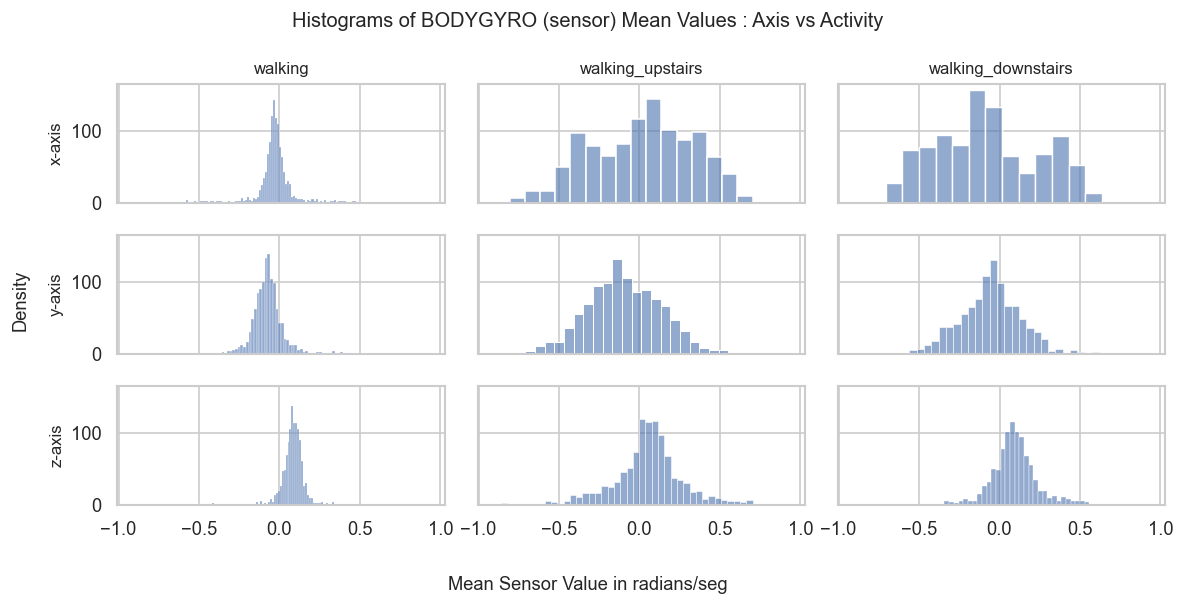

In [16]:
# Compare sensor-feature distributions based on activity
# for each of the six activities, compare the per-axis/per-128 sensor reading - MEAN DISTRIBUTION
# CASE 2: MOBILE + BODYGYRO
# ACTIVITY = MOBILE {'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'}, SENSOR = BODYACC

actsToAnalyze = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

sensor_name = 'BodyGyro'
#sensor_unit = "Units of g (9.80665 m/seg-squared)"
sensor_unit = sensor_units[sensor_name]
# feature to analyze: always per-axis mean
sensor_XYZ_features = [f't{sensor_name}-mean()-X', 
                       f't{sensor_name}-mean()-Y', 
                       f't{sensor_name}-mean()-Z']
                    
                    

print(f'Sensor_XYZ_features: {sensor_XYZ_features}')
fig=[]
axes=[]

fig, axes = plt.subplots(3, len(actsToAnalyze), figsize=(10, 5), dpi=120, sharex=True, sharey=True)

for act_id, activity in enumerate(actsToAnalyze):
    filtered_train_data = train_data[train_data['activity']==activity]
    # set column title to activity label
    axes[0,act_id].set_title(f"{activity.lower()}", fontsize=10)
    
    for xyz_id, xyz_feature in enumerate(sensor_XYZ_features):
        # display feature stat
        sns.histplot(filtered_train_data[xyz_feature], ax=axes[xyz_id,act_id], fill=True, alpha=0.6)
        axes[xyz_id,0].set_ylabel(f"{xyz_feature[-1].lower()}-axis", fontsize=10)
        axes[xyz_id,act_id].set_xlabel("")

#fig.suptitle(f'Per-Axis MEAN Values for Sensor {sensor_name.upper()}', fontsize=11)
fig.supylabel(f'Density', fontsize=11)
fig.suptitle(f'Histograms of {sensor_name.upper()} (sensor) Mean Values : Axis vs Activity', fontsize=12)
fig.supxlabel(f'Mean Sensor Value in {sensor_unit}', fontsize=11)
plt.tight_layout()

plt.show()

Sensor_XYZ_features: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z']


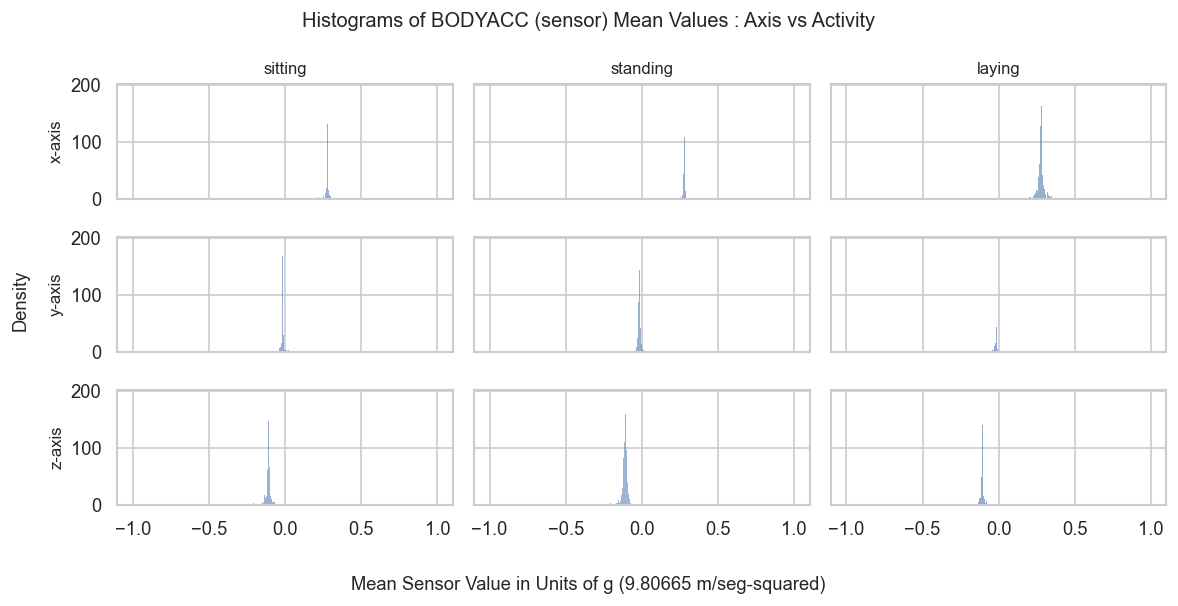

In [17]:
# Compare sensor-feature distributions based on activity
# for each of the six activities, compare the per-axis/per-128 sensor reading - MEAN DISTRIBUTION
# CASE 3: STATIONARY + BODYACC
# ACTIVITY = MOBILE {'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'}, SENSOR = BODYACC

actsToAnalyze = ['SITTING', 'STANDING', 'LAYING']

sensor_name = 'BodyAcc'
#sensor_unit = "Units of g (9.80665 m/seg-squared)"
sensor_unit = sensor_units[sensor_name]
# feature to analyze: always per-axis mean
sensor_XYZ_features = [f't{sensor_name}-mean()-X', 
                       f't{sensor_name}-mean()-Y',
                       f't{sensor_name}-mean()-Z']
                    
                    

print(f'Sensor_XYZ_features: {sensor_XYZ_features}')
fig=[]
axes=[]

fig, axes = plt.subplots(3, len(actsToAnalyze), figsize=(10, 5), dpi=120, sharex=True, sharey=True)

for act_id, activity in enumerate(actsToAnalyze):
    filtered_train_data = train_data[train_data['activity']==activity]
    # set column title to activity label
    axes[0,act_id].set_title(f"{activity.lower()}", fontsize=10)
    
    for xyz_id, xyz_feature in enumerate(sensor_XYZ_features):
        # display feature stat
        sns.histplot(filtered_train_data[xyz_feature], ax=axes[xyz_id,act_id], fill=True, alpha=0.6)
        axes[xyz_id,0].set_ylabel(f"{xyz_feature[-1].lower()}-axis", fontsize=10)
        axes[xyz_id,act_id].set_xlabel("")

#fig.suptitle(f'Per-Axis MEAN Values for Sensor {sensor_name.upper()}', fontsize=11)
fig.supylabel(f'Density', fontsize=11)
fig.suptitle(f'Histograms of {sensor_name.upper()} (sensor) Mean Values : Axis vs Activity', fontsize=12)
fig.supxlabel(f'Mean Sensor Value in {sensor_unit}', fontsize=11)
plt.tight_layout()

plt.show()

Sensor_XYZ_features: ['tBodyGyro-mean()-X', 'tBodyGyro-mean()-Y', 'tBodyGyro-mean()-Z']


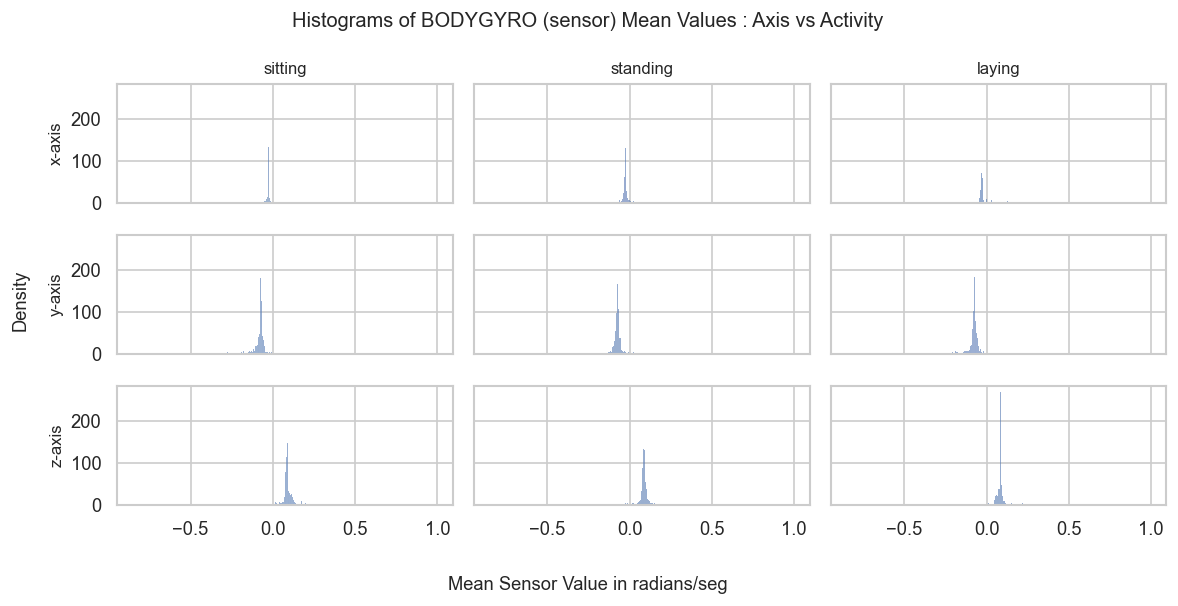

In [18]:
# Compare sensor-feature distributions based on activity
# for each of the six activities, compare the per-axis/per-128 sensor reading - MEAN DISTRIBUTION
# CASE 4: STATIONARY + BODYGYRO
# ACTIVITY = MOBILE {'WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'}, SENSOR = BODYACC

actsToAnalyze = ['SITTING', 'STANDING', 'LAYING']

sensor_name = 'BodyGyro'
#sensor_unit = "Units of g (9.80665 m/seg-squared)"
sensor_unit = sensor_units[sensor_name]
# feature to analyze: always per-axis mean
sensor_XYZ_features = [f't{sensor_name}-mean()-X', 
                       f't{sensor_name}-mean()-Y',
                       f't{sensor_name}-mean()-Z']
                    
                    

print(f'Sensor_XYZ_features: {sensor_XYZ_features}')
fig=[]
axes=[]

fig, axes = plt.subplots(3, len(actsToAnalyze), figsize=(10, 5), dpi=120, sharex=True, sharey=True)

for act_id, activity in enumerate(actsToAnalyze):
    filtered_train_data = train_data[train_data['activity']==activity]
    # set column title to activity label
    axes[0,act_id].set_title(f"{activity.lower()}", fontsize=10)
    
    for xyz_id, xyz_feature in enumerate(sensor_XYZ_features):
        # display feature stat
        sns.histplot(filtered_train_data[xyz_feature], ax=axes[xyz_id,act_id], fill=True, alpha=0.6)
        axes[xyz_id,0].set_ylabel(f"{xyz_feature[-1].lower()}-axis", fontsize=10)
        axes[xyz_id,act_id].set_xlabel("")

#fig.suptitle(f'Per-Axis MEAN Values for Sensor {sensor_name.upper()}', fontsize=11)
fig.supylabel(f'Density', fontsize=11)
fig.suptitle(f'Histograms of {sensor_name.upper()} (sensor) Mean Values : Axis vs Activity', fontsize=12)
fig.supxlabel(f'Mean Sensor Value in {sensor_unit}', fontsize=11)
plt.tight_layout()

plt.show()

In [19]:
# remove first two columns of train and test data to create X_train and X_test
# train
X_train = train_data.iloc[:, 2:]
y_train = train_data.iloc[:, 1]
display(X_train.head())
display(y_train.head())

# test
X_test = test_data.iloc[:, 2:]
y_test = test_data.iloc[:, 1]
display(X_test.head())
display(y_test.head())

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # Convert labels to numbers
y_test_encoded = label_encoder.transform(y_test)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


0    STANDING
1    STANDING
2    STANDING
3    STANDING
4    STANDING
Name: activity, dtype: object

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,0.071645,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.401189,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,0.062891,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,0.116695,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.121711,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857


0    STANDING
1    STANDING
2    STANDING
3    STANDING
4    STANDING
Name: activity, dtype: object

# Part II: MACHINE LEARNING TASK 1 (HUMAN ACTIVITY CLASSIFICATION)

### Part II.a RandomForestClassifier

In [20]:
import ClassifierHelperFunctions as chf
reload(chf)

<module 'ClassifierHelperFunctions' from '/Users/geoffreyfadera/Documents/USD Stuff/AAI-530/TeamProject/Personal-Health-Activity-Tracker/ClassifierHelperFunctions.py'>

In [21]:
# Classifier Model 1: Random Forest
model_name = "Random Forest Classifier"
# train model and display learning curves if available
rf_model=[]
rf_model = chf.classifier_RF(X_train, y_train, n_estimators=100)

# predict activity labels on test data
y_pred = chf.classifier_predict(rf_model, X_test, label_encoder=[], model_id=0)

# evaluate predictions against true labels
rf_acc, rf_classreport = chf.classifier_evaluate(y_true=y_test, y_pred=y_pred, model_name=model_name)

Random Forest Classifier
accuracy score: 0.9237
Classification Report Random Forest Classifier
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.90      0.89      0.89       491
          STANDING       0.90      0.91      0.90       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.96      0.85      0.90       420
  WALKING_UPSTAIRS       0.91      0.91      0.91       471

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



### Part II.b LSTM Classifier

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │       160,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,870 (675.27 KB)

 Trainable params: 172,870 (675.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5909 - loss: 1.1221 - val_accuracy: 0.9220 - val_loss: 0.2642
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9191 - loss: 0.2549 - val_accuracy: 0.9352 - val_loss: 0.1854
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9465 - loss: 0.1509 - val_accuracy: 0.9345 - val_loss: 0.1702
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9592 - loss: 0.1122 - val_accuracy: 0.9464 - val_loss: 0.1463
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9699 - loss: 0.0921 - val_accuracy: 0.9420 - val_loss: 0.1617
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9662 - loss: 0.0928 - val_accuracy: 0.9403 - val_loss: 0.1662
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9724 - loss: 0.0752 - val_accuracy: 0.9389 - val_loss: 0.1759
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9756 - loss: 0.0721 - val_accuracy: 0.

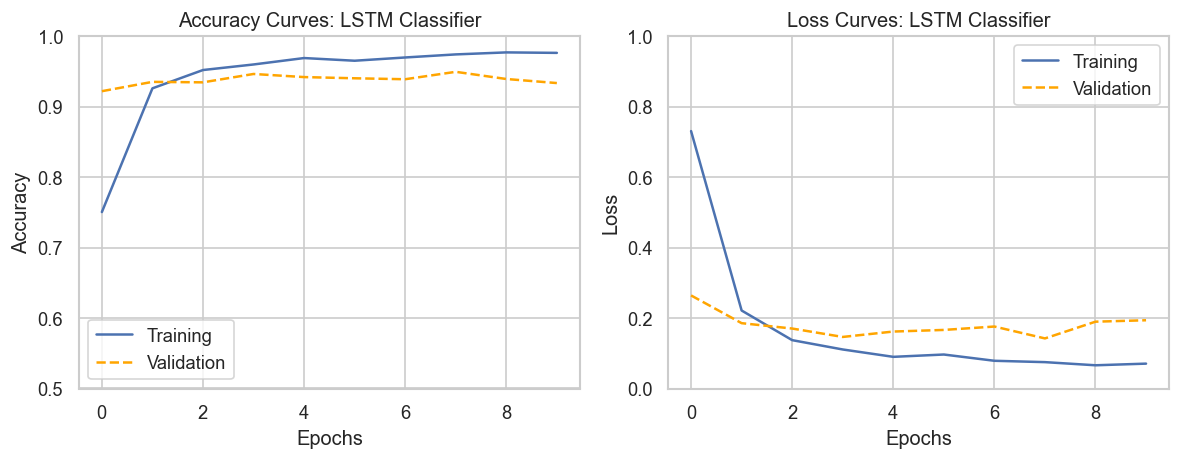

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
LSTM Classifier
accuracy score: 0.9335
Classification Report LSTM Classifier
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.88      0.94      0.91       491
          STANDING       0.95      0.88      0.91       532
           WALKING       0.92      0.98      0.95       496
WALKING_DOWNSTAIRS       0.99      0.87      0.93       420
  WALKING_UPSTAIRS       0.89      0.92      0.90       471

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



In [22]:
# Classifier Model 2: LSTM Classifier
model_name = "LSTM Classifier"

# train model and display learning curves if available
lstm_classifier=[]
lstm_classifier, lstm_classifier_history = chf.classifier_LSTM(X_train, y_train, 
                                                               X_test, y_test,
                                                               label_encoder = label_encoder, 
                                                               epochs = 10,
                                                               batch_size = 32, #validation_split = 0.2,
                                                               model_name = model_name)

# predict activity labels on test data
# Reshape X_test for LSTM Classifier (samples, time_steps, features)
X_test_lstm = np.array(X_test).reshape((-1, 1, X_test.shape[1]))
y_pred = chf.classifier_predict(lstm_classifier, X_test_lstm, label_encoder=label_encoder, model_id=1)

# evaluate predictions against true labels
lc_acc, lc_classreport = chf.classifier_evaluate(y_true=y_test, y_pred=y_pred, model_name=model_name)


### Part II.c CNN Classifier

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 559, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 557, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 557, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 278, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 17792)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │     1,779,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792,514 (6.84 MB)

 Trainable params: 1,792,514 (6.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7673 - loss: 0.5768 - val_accuracy: 0.9355 - val_loss: 0.1740
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9659 - loss: 0.0966 - val_accuracy: 0.9528 - val_loss: 0.1258
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9725 - loss: 0.0706 - val_accuracy: 0.9467 - val_loss: 0.1461
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9825 - loss: 0.0496 - val_accuracy: 0.9440 - val_loss: 0.1438
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9821 - loss: 0.0534 - val_accuracy: 0.9447 - val_loss: 0.1753
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9829 - loss: 0.0432 - val_accuracy: 0.9264 - val_loss: 0.2637
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9896 - loss: 0.0302 - val_accuracy: 0.9498 - val_loss: 0.1496
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9898 - loss: 0.0274 - val_accu

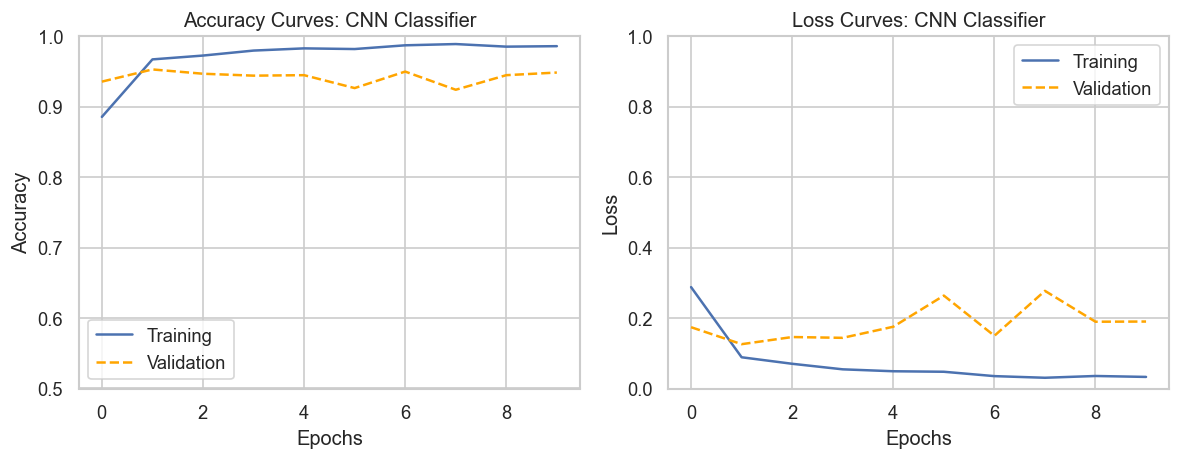

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
CNN Classifier
accuracy score: 0.9484
Classification Report CNN Classifier
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       1.00      0.82      0.90       491
          STANDING       0.86      0.99      0.92       532
           WALKING       0.95      0.98      0.97       496
WALKING_DOWNSTAIRS       0.99      0.93      0.96       420
  WALKING_UPSTAIRS       0.92      0.95      0.94       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [23]:
# Classifier Model 3: CNN Classifier
model_name = "CNN Classifier"

# train model and display learning curves if available
cnn_classifier=[]
cnn_classifier, cnn_classifier_history = chf.classifier_CNN(X_train, y_train, 
                                                            X_test, y_test,
                                                            label_encoder = label_encoder, 
                                                            epochs = 10,
                                                            batch_size = 32, #validation_split = 0.2,
                                                            model_name = model_name)

# predict activity labels on test data
# Reshape Data for CNN Classifier (samples, features)
y_pred = chf.classifier_predict(cnn_classifier, X_test, label_encoder=label_encoder, model_id=2)

# evaluate predictions against true labels
cnn_acc, cnn_classreport = chf.classifier_evaluate(y_true=y_test, y_pred=y_pred, model_name=model_name)



## Classifier Performance Analysis
The deep learning classifiers (LSTM & CNN) outperformed the Random Forest Classifier.
The learning curves for both LSTM and CNN classifiers show overfitting but not by any significant margin. 
Based on the f1-scores per activity and total accuracy, CNN is the best performing model.
We have decided to use this classifier model on our Dashboard

# Part III: MACHINE LEARNING TASK 2 (TIME-SERIES PREDICTION)

In [24]:
import TimeSeriesHelperFunctions as tshf
reload(tshf)

TS_NUM_EPOCHS = 10
TS_BATCH_SIZE = 500
TS_VAL_SPLIT = 0.2

TimeSeriesPredictor for SENSOR: body_acc and MODEL: Time-Series Forecaster Using the Sensor body_acc
TS_STEP 1: Load train xyz data for SENSOR (body_acc)
TS_STEP 2: scale train xyz data per x,y,z axis using MinMaxScaler
TS_STEP 3: split scaled train xyz data into two along the time-axis (axis=1)
TS_STEP 4: Create, train, and save a TimeSeriesPredictor
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 451ms/step - loss: 14.1067 - mae: 0.4343 - mse: 0.2115 - val_loss: 2.8537 - val_mae: 0.0843 - val_mse: 0.0162
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 402ms/step - loss: 3.0430 - mae: 0.1161 - mse: 0.0235 - val_loss: 1.7913 - val_mae: 0.0759 - val_mse: 0.0115
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 481ms/step - loss: 2.0630 - mae: 0.1007 - mse: 0.0176 - val_loss: 1.2378 - val_mae: 0.0555 - val_mse: 0.0078
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 419ms/step - loss: 1.5444 - mae: 0.0912 - mse: 0.0143 - val_loss: 0.8326 - val_mae: 0.0435 - val_mse: 0.0055
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 440m

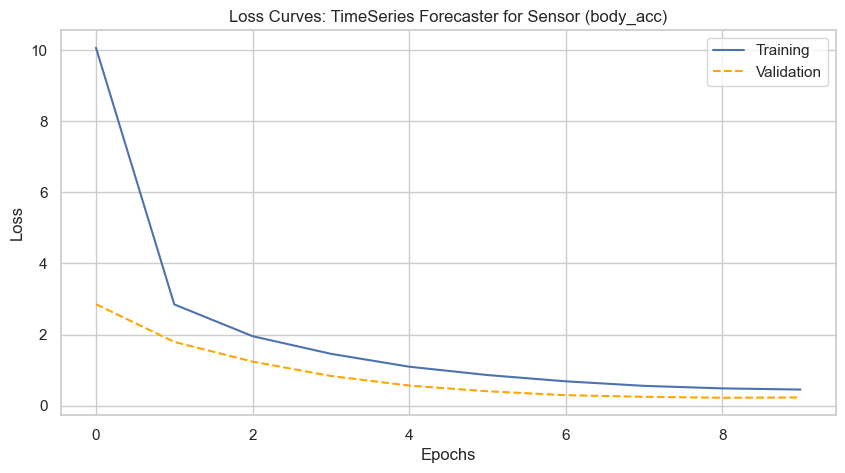

TS_STEP 6: Load test xyz data for SENSOR body_acc
TS_STEP 7: Evaluate model on test data
93/93 - 2s - 22ms/step - loss: 0.2321 - mae: 0.0419 - mse: 0.0037
Metrics on Scaled Test Data:
    MSE (scaled): 0.2321
    RMSE (scaled): 0.4818
    MAE (scaled): 0.0037
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
PRED SHAPE: (2947, 64, 3)
Metrics on Unscaled Test Data:
  x-axis:
    MSE: 0.0355
    RMSE: 0.1884
    MAE: 0.1187
    'TraceMSE': 2.2516
  y-axis:
    MSE: 0.0184
    RMSE: 0.1358
    MAE: 0.1036
    'TraceMSE': 1.1846
  z-axis:
    MSE: 0.0120
    RMSE: 0.1097
    MAE: 0.0832
    'TraceMSE': 0.7410
  xyz-Combined:
    MSE: 0.0220
    RMSE: 0.1483
    MAE: 0.1019
    'TraceMSE': 1.3924
/n
TimeSeries Forecaster Evaluation Metrics for Sensor body_acc


,x-axis,y-axis,z-axis,xyz-Combined
MSE,0.035505,0.018429,0.012027,0.021987
RMSE,0.188427,0.135755,0.109668,0.148281
MAE,0.118676,0.103637,0.083247,0.101853
TraceMSE,2.251556,1.184557,0.740966,1.392360


In [25]:
# time-series predictor for sensor BODY_ACC
sensor_name = 'body_acc' #, 'body_gyro', 'total_acc']
loss_function = 'trace_mse_loss'
model_name = f"Time-Series Forecaster Using the Sensor {sensor_name}"
ts_metrics_on_test1 = {}

# predictor 
ts_model1, ts_history1, ts_sensor_scalers1, ts_metrics_on_test1 = tshf.time_series_predictor_pipeline(
    root_dir = DATASET_DIR,
    sensor_name = sensor_name,
    model_name = model_name,
    user_loss_fn = loss_function,
    num_epochs= TS_NUM_EPOCHS,
    batch_size=TS_BATCH_SIZE,
    val_split=TS_VAL_SPLIT,
    debug_mode = True)

print("/n")
print(f"TimeSeries Forecaster Evaluation Metrics for Sensor {sensor_name}")

pd.DataFrame(ts_metrics_on_test1)

TimeSeriesPredictor for SENSOR: body_gyro and MODEL: Time-Series Forecaster Using the Sensor body_gyro
TS_STEP 1: Load train xyz data for SENSOR (body_gyro)
TS_STEP 2: scale train xyz data per x,y,z axis using MinMaxScaler
TS_STEP 3: split scaled train xyz data into two along the time-axis (axis=1)
TS_STEP 4: Create, train, and save a TimeSeriesPredictor
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 476ms/step - loss: 11.9516 - mae: 0.3947 - mse: 0.1772 - val_loss: 2.6623 - val_mae: 0.0795 - val_mse: 0.0143
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 426ms/step - loss: 2.7801 - mae: 0.1083 - mse: 0.0204 - val_loss: 1.5982 - val_mae: 0.0931 - val_mse: 0.0126
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step - loss: 1.8678 - mae: 0.0984 - mse: 0.0164 - val_loss: 1.2102 - val_mae: 0.0544 - val_mse: 0.0068
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 443ms/step - loss: 1.4872 - mae: 0.0890 - mse: 0.0133 - val_loss: 1.0006 - val_mae: 0.0394 - val_mse: 0.0052
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 

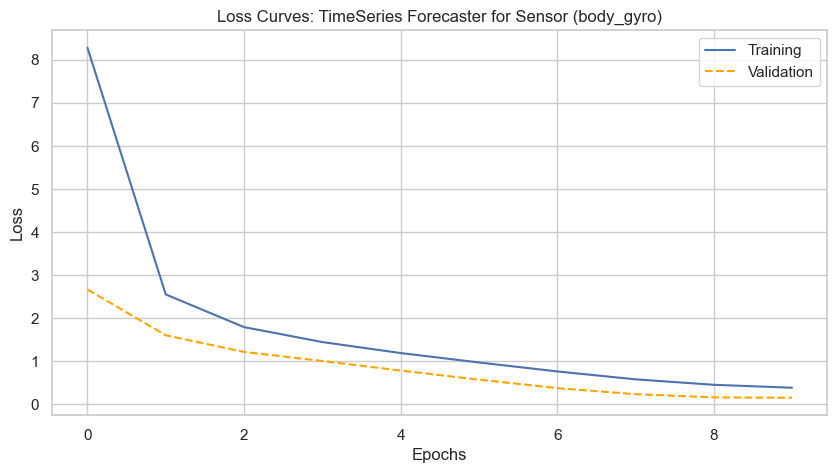

TS_STEP 6: Load test xyz data for SENSOR body_gyro
TS_STEP 7: Evaluate model on test data
93/93 - 2s - 22ms/step - loss: 0.1422 - mae: 0.0334 - mse: 0.0022
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step
PRED SHAPE: (2947, 64, 3)
/n
TimeSeries Forecaster Evaluation Metrics for Sensor body_gyro


,x-axis,y-axis,z-axis,xyz-Combined
MSE,0.170138,0.187729,0.078081,0.145316
RMSE,0.412478,0.433277,0.279430,0.381204
MAE,0.286852,0.327224,0.205940,0.273339
TraceMSE,10.609845,13.079007,5.186324,9.625059


In [26]:
# time-series predictor for sensor BODY_GYRO
sensor_name = 'body_gyro' #, 'body_gyro', 'total_acc']
loss_function = 'trace_mse_loss'
model_name = f"Time-Series Forecaster Using the Sensor {sensor_name}"
ts_metrics_on_test2 = {}

# predictor 
ts_model2, ts_history2, ts_sensor_scalers2, ts_metrics_on_test2 = tshf.time_series_predictor_pipeline(
    root_dir = DATASET_DIR,
    sensor_name = sensor_name,
    model_name = model_name,
    user_loss_fn = loss_function,
    num_epochs= TS_NUM_EPOCHS,
    batch_size=TS_BATCH_SIZE,
    val_split=TS_VAL_SPLIT,
    debug_mode = False)

print("/n")
print(f"TimeSeries Forecaster Evaluation Metrics for Sensor {sensor_name}")

pd.DataFrame(ts_metrics_on_test2)

# Part IV: Dashboard Data Preparation
The project's primary objective is to display activity statistics/information on ANY new user based on the readings from the accelerometer and gyroscope sensors available. It only makes sense to present a Dashboard of human activity metrics based on data from ONE specific person only. The following code section demonstrates this concept.

In [27]:
import TimeSeriesHelperFunctions as tshf
reload(tshf)

import ClassifierHelperFunctions as chf
reload(chf)

<module 'ClassifierHelperFunctions' from '/Users/geoffreyfadera/Documents/USD Stuff/AAI-530/TeamProject/Personal-Health-Activity-Tracker/ClassifierHelperFunctions.py'>

In [28]:
# Specify subject id from Test Set to be used on the dashboard
dashboard_human_id = 20

In [29]:
# Classifier
# filter test data and use only those rows matching 'dashboard_human_id' 
test_data_person = test_data[test_data['subject']== dashboard_human_id]
X_test_person = test_data_person.iloc[:, 2:]
y_test_person = test_data_person.iloc[:, 1]

# predict the activity label given a human subject 
y_pred_person = chf.classifier_predict(cnn_classifier, X_test_person, label_encoder=label_encoder, model_id=2)
display(y_pred_person.shape)

# save to csv
y_pred_person_df = pd.DataFrame(y_pred_person, columns=["Activity"])
y_pred_person_df.to_csv("predicted_activities_v3.csv", index=True)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


(354,)

In [30]:
# get lstm predictions on sensor body_acc
sensor_name = 'body_acc'

test_sensor_XYZ, test_activity, test_subject = tshf.load_sensor_label_data(root_dir=DATASET_DIR, train_test = 'test', sensor_name=sensor_name)
test_sensor_XYZ_person = test_sensor_XYZ[np.where(test_subject==dashboard_human_id)[0], :, :]
display(test_sensor_XYZ_person.shape)

ts_metrics_person, ts_y_pred_person, ts_y_true_person, ts_X_test_person = tshf.evaluate_XYZ_predictor(
        ts_model1, # trained model
        test_sensor_XYZ_person,
        ts_sensor_scalers1, #MinMaxScaler fitted on Train data
        debug_mode=False
        )

pd.DataFrame(ts_metrics_person)


(354, 128, 3)

12/12 - 0s - 21ms/step - loss: 0.2832 - mae: 0.0455 - mse: 0.0046
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
PRED SHAPE: (354, 64, 3)


,x-axis,y-axis,z-axis,xyz-Combined
MSE,0.039141,0.029526,0.012342,0.027003
RMSE,0.197841,0.171831,0.111097,0.164326
MAE,0.123103,0.123754,0.083902,0.110253
TraceMSE,2.420517,1.879752,0.728683,1.676317


In [31]:
# function to compare predicted and actual time-series values
def display_time_series_pred_vs_actual(y_true, y_pred, sensor_name, prev_samples=-1, use_mean=True):
    

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=120, sharex=True, sharey=True)
    for axis in range(3):
        if(use_mean==True):
            y_true_axis = np.mean(y_true[:,:,axis], axis=1)
            y_pred_axis = np.mean(y_pred[:,:,axis], axis=1)
        else:
            y_true_axis = y_true[:,:,axis].flatten()
            y_pred_axis = y_pred[:,:,axis].flatten()

        if prev_samples == '-1':
            prev_samples = len(y_true_axis)

        axes[axis].plot(y_true_axis[-prev_samples:], label=f"Actual")
        axes[axis].plot(y_pred_axis[-prev_samples:], label=f"Predicted", linestyle="dashed", color="orange")
        
        axes[axis].set_title(f"{chr(88+axis)}-axis")
        #axes[axis].set_xlabel("Time Steps")
        #axes[axis].set_ylabel("Sensor Value")
    
    fig.supxlabel(f'Time Steps', fontsize=11)
    fig.supylabel(f'Sensor Value', fontsize=11)
    fig.suptitle(f"Predictions vs. Actual Data for Sensor ({sensor_name})")
    plt.legend()
    plt.show()


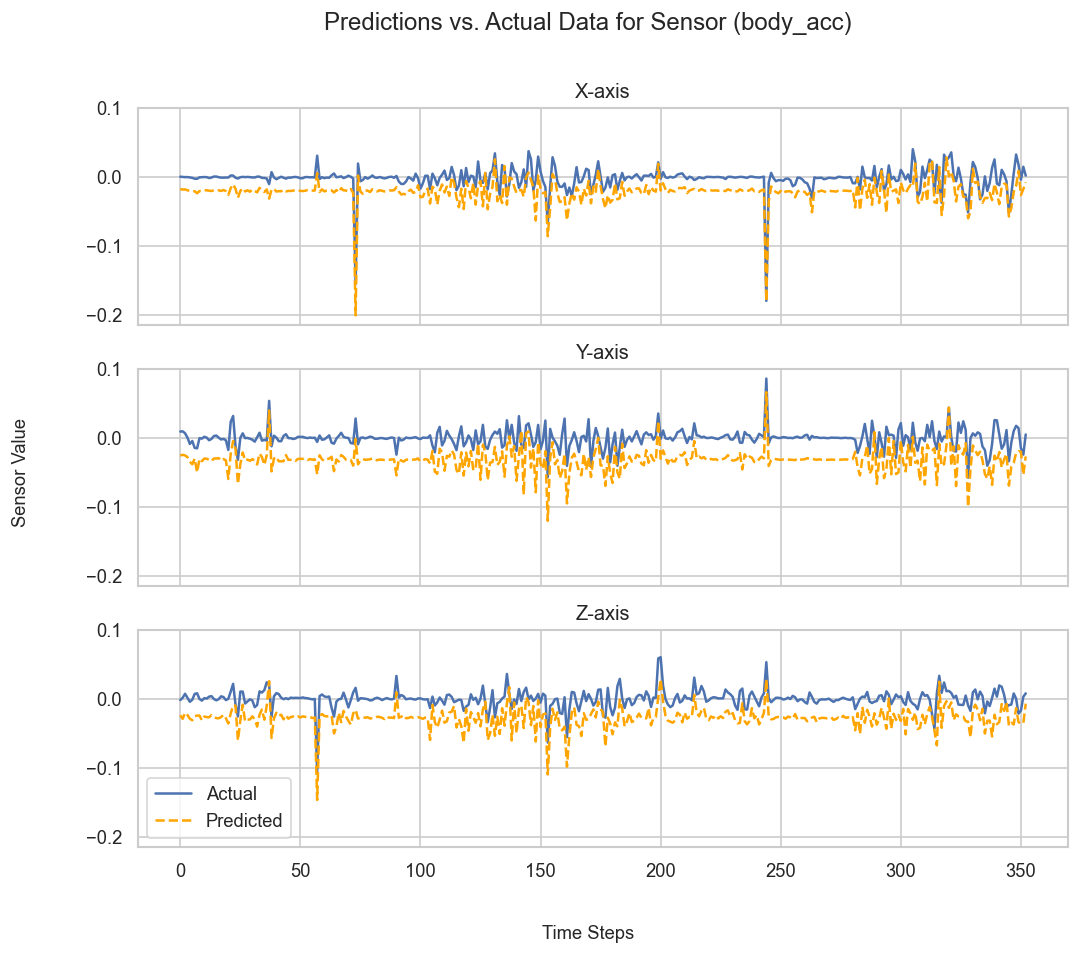

In [32]:
# create per 128 TRUE sensor readings, and PREDICTED sensor readings
true_acc_128 = np.concatenate((ts_X_test_person, ts_y_true_person), axis = 1)
pred_acc_128 = np.concatenate((ts_X_test_person, ts_y_pred_person), axis = 1)
display_time_series_pred_vs_actual(true_acc_128, pred_acc_128, sensor_name, use_mean=True)

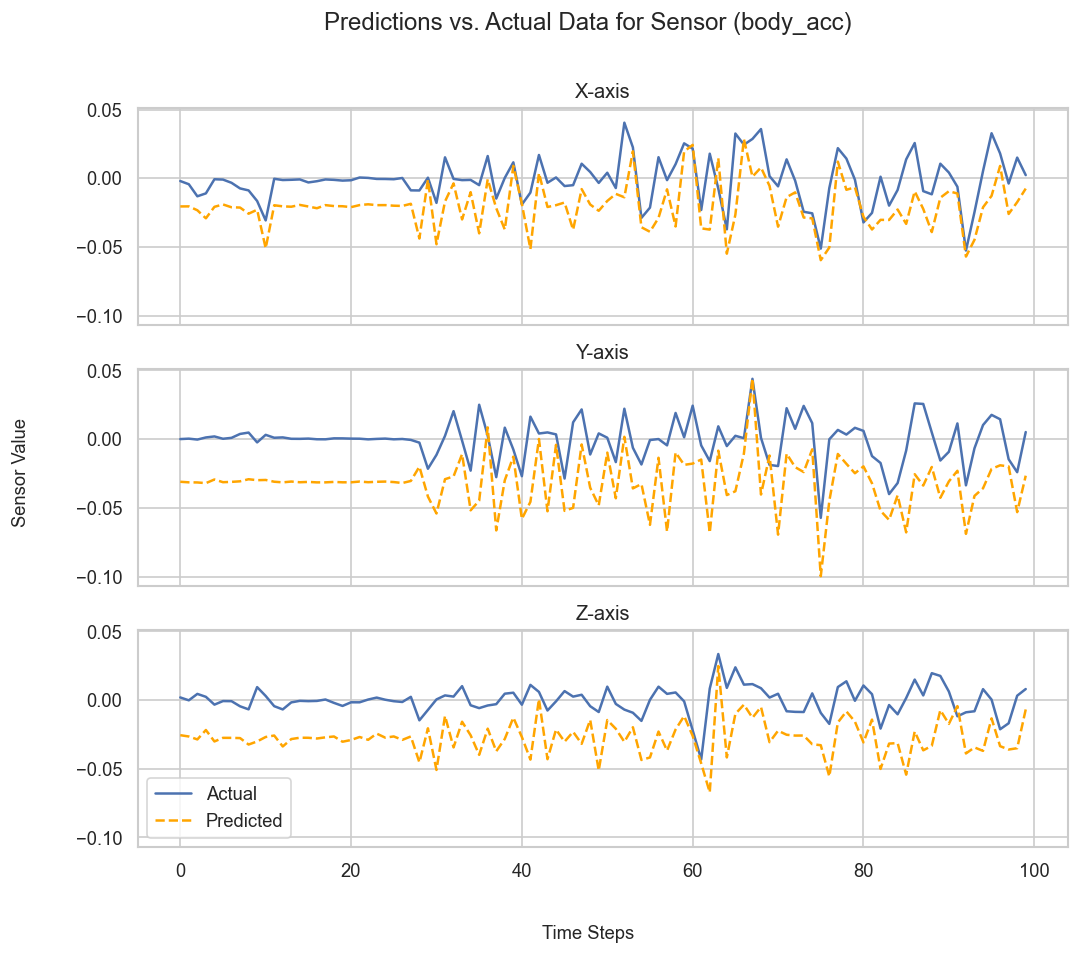

In [33]:
display_time_series_pred_vs_actual(true_acc_128, pred_acc_128, sensor_name, prev_samples=100, use_mean=True)

(354, 128, 3)

12/12 - 0s - 19ms/step - loss: 0.3267 - mae: 0.0539 - mse: 0.0051
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
PRED SHAPE: (354, 64, 3)


,x-axis,y-axis,z-axis,xyz-Combined
MSE,0.624521,0.364217,0.121863,0.370200
RMSE,0.790266,0.603504,0.349089,0.608441
MAE,0.705902,0.474766,0.214552,0.465073
TraceMSE,41.033166,22.814484,7.750465,23.866038


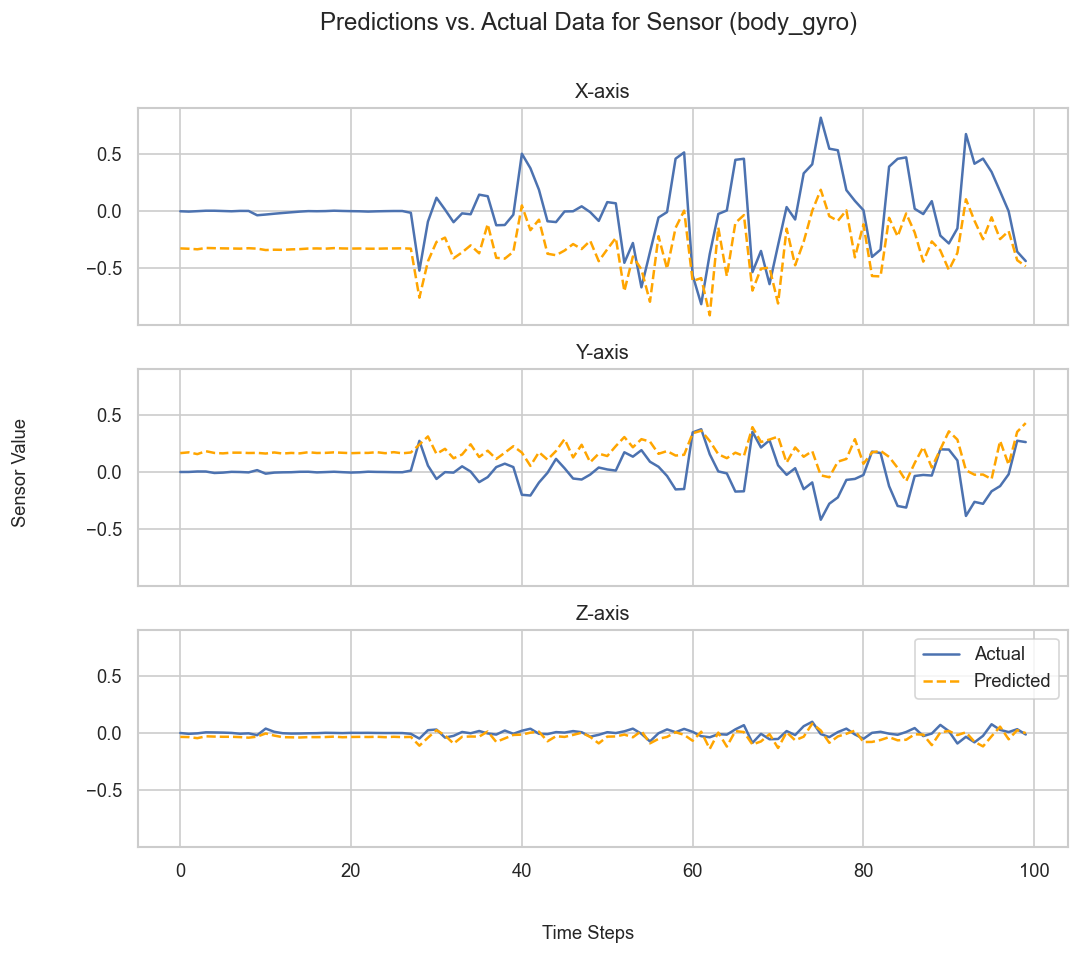

In [34]:
sensor_name = 'body_gyro'

test_sensor_XYZ, test_activity, test_subject = tshf.load_sensor_label_data(root_dir=DATASET_DIR, train_test = 'test', sensor_name=sensor_name)
test_sensor_XYZ_person = test_sensor_XYZ[np.where(test_subject==dashboard_human_id)[0], :, :]
display(test_sensor_XYZ_person.shape)

ts_metrics_person2, ts_y_pred_person2, ts_y_true_person2, ts_X_test_person2 = tshf.evaluate_XYZ_predictor(
        ts_model1, # trained model
        test_sensor_XYZ_person,
        ts_sensor_scalers2, #MinMaxScaler fitted on Train data
        debug_mode=False
        )

display(pd.DataFrame(ts_metrics_person2))

# create per 128 TRUE sensor readings, and PREDICTED sensor readings
true_gyro_128 = np.concatenate((ts_X_test_person2, ts_y_true_person2), axis = 1)
pred_gyro_128 = np.concatenate((ts_X_test_person2, ts_y_pred_person2), axis = 1)
display_time_series_pred_vs_actual(true_gyro_128, pred_gyro_128, sensor_name, prev_samples=100, use_mean=True)

In [35]:
# create per 128 TRUE sensor readings, and PREDICTED sensor readings
#np.mean(y_true[:,:,axis], axis=1)

true_acc_128_mean = np.mean(true_acc_128,axis=1)
pred_acc_128_mean = np.mean(pred_acc_128,axis=1)
true_gyro_128_mean = np.mean(true_gyro_128,axis=1)
pred_gyro_128_mean = np.mean(pred_gyro_128,axis=1)
display(true_acc_128_mean.shape)

# save to csv
sensor_means_with_preds_df = pd.DataFrame({
                                        'Acc True-X': true_acc_128_mean[:,0], 
                                        'Acc True-Y': true_acc_128_mean[:,1], 
                                        'Acc True-Z': true_acc_128_mean[:,2],
                                        'Acc Pred-X': pred_acc_128_mean[:,0], 
                                        'Acc Pred-Y': pred_acc_128_mean[:,1], 
                                        'Acc Pred-Z': pred_acc_128_mean[:,2],
                                        'Gyro True-X': true_gyro_128_mean[:,0], 
                                        'Gyro True-Y': true_gyro_128_mean[:,1],
                                        'Gyro True-Z': true_gyro_128_mean[:,2],
                                        'Gyro Pred-X': pred_gyro_128_mean[:,0], 
                                        'Gyro Pred-Y': pred_gyro_128_mean[:,1], 
                                        'Gyro Pred-Z': pred_gyro_128_mean[:,2]})
                                        
sensor_means_with_preds_df.to_csv("sensor_means_with_preds_v3.csv", index=True)


(354, 3)